---

<table style="width:100%">
  <tr>
    <th>
        <div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> Конспект лекцій з предмету: </p>
<p style="text-align: center;"><b><h2>"Електронні прилади та мікроелектроніка"</h2></b></p>
<p style="text-align: center;"><b><h3>Лекція 7. Біполярний транзистор у підсилювальному та ключовому режимах</h3></b></p>
<p style="text-align: center;"> Національний університет "Чернігівська політехніка"</p>
<p style="text-align: center;"><b>Кафедра:</b> Радіотехніки та відеоінформаційних систем (РТВС)</p>
<hr/>
<p style="text-align: center;"><b>Теми лекції:</b></p>
<ul style="text-align: left;">
  <li>Малосигнальна (гібридна П-подібна) модель біполярного транзистора</li>
  <li>Частотні властивості: граничні частоти $f_\beta$, $f_T$</li>
  <li>Підсилювальний каскад зі спільним емітером: коефіцієнт підсилення, АЧХ</li>
  <li>Ефект Міллера і способи розширення смуги</li>
  <li>Транзистор у ключовому режимі: перехідні процеси, час розсмоктування, ключ Шотки</li>
</ul>
</div>
    </th>
    <th>
<div style="text-align: center; background-color: #f0f0f0; padding: 20px; border-radius: 10px;">
<p style="text-align: center;"> <b>Викладач:</b> </p>
<p style="text-align: center;"> Доктор філософії, Кафедра РТВС</p>
<p style="text-align: center;"> Пахалюк Богдан Петрович</p>
<img src="./Teacher.jpg" alt="" width="110" >
<hr/>
<p style="text-align: center; font-size: 0.9em;">Лекція 7 з 13</p>
</div>
    </th>
  </tr>
</table>

---

---

<p style="text-align: center;"><b>Зміст</b></p>

* [Малосигнальна модель біполярного транзистора](#hybrid-pi)
* [Частотні властивості](#bjt-frequency)
    * [⚙️ PySpice: частотна залежність h21е і гранична частота 2N3904](#spice-ft)
* [Підсилювальний каскад зі спільним емітером](#ce-amplifier)
    * [⚙️ PySpice: підсилювач СЕ — осцилограми і АЧХ](#spice-ce-amp)
    * [Ефект Міллера](#miller)
* [Транзистор у ключовому режимі](#bjt-switch)
    * [⚙️ PySpice: перехідні процеси в транзисторному ключі](#spice-switch)
* [📌 Підсумок лекції](#summary)
* [📚 Рекомендована література](#references)

> 💡 Код демонстрацій та інтерактивних графіків **згорнуто**, щоб не відволікати від матеріалу. Щоб переглянути його, натисніть на «⋯» (або на смужку ліворуч від комірки). Для роботи інтерактивних елементів виконайте всі комірки: *Run → Run All Cells*. Позначка 🔬 — інтерактивне моделювання (повзунки), ⚙️ — моделювання схеми в **PySpice/ngspice**.

---

**Підключення бібліотек.** NumPy/Matplotlib — чисельні розрахунки та графіки, ipywidgets — інтерактивні повзунки, PySpice + ngspice — схемотехнічне моделювання, schemdraw — побудова схем з умовними позначеннями за ДСТУ/IEC. SPICE-моделі реальних приладів зібрано в теці `models/`. Цю комірку потрібно виконати першою.

In [1]:
import warnings
warnings.filterwarnings('ignore', message='Unable to import Axes3D')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from ipywidgets import interact, interactive, fixed, HBox, VBox, Output
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown
%matplotlib inline

import PySpice.Logging.Logging as Logging
logger = Logging.setup_logging(logging_level='ERROR')
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *

# ngspice ≥ 41 пише в stderr інформаційні повідомлення (напр. "Using SPARSE 1.3 as Direct Linear Solver"),
# які PySpice 1.5 вважає помилкою симуляції. Сприймаємо як помилку лише рядки, що містять "error".
from PySpice.Spice.NgSpice import Shared as _ngspice_shared
_orig_send_char = _ngspice_shared.NgSpiceShared._send_char
def _send_char(message_c, ngspice_id, user_data):
    message = _ngspice_shared.ffi_string_utf8(message_c)
    prefix, _, content = message.partition(' ')
    if prefix == 'stderr' and 'error' not in content.lower() and 'init file' not in content:
        self = _ngspice_shared.ffi.from_handle(user_data)
        self._stderr.append(content)
        return self.send_char(message, ngspice_id)
    return _orig_send_char(message_c, ngspice_id, user_data)
_ngspice_shared.NgSpiceShared._send_char = staticmethod(_send_char)

MODELS = 'models'   # тека з SPICE-моделями реальних приладів
def lib(name):
    """Шлях до бібліотеки моделей: lib('diodes') -> models/diodes.lib"""
    return f'{MODELS}/{name}.lib'

try:
    import schemdraw
    import schemdraw.elements as elm
    SCHEMDRAW_AVAILABLE = True
except ImportError:
    SCHEMDRAW_AVAILABLE = False
    print('schemdraw не встановлено (pip install schemdraw)')

plt.rcParams.update({
    'figure.figsize': (8, 4), 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.labelsize': 12, 'axes.titlesize': 13, 'lines.linewidth': 2,
    'font.size': 11,
})

if SCHEMDRAW_AVAILABLE:
    # Умовні позначення за ДСТУ/IEC: резистор — прямокутник, джерело ЕРС — коло зі стрілкою
    from schemdraw.segments import Segment
    from schemdraw.elements.transistors import jfetw, fetl
    elm.style(elm.STYLE_IEC)

    class EMF(elm.Source):
        """Джерело ЕРС: стрілка всередині кола вказує напрямок дії ЕРС."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.2, 0), (.8, 0)], arrow='->', arrowwidth=.16, arrowlength=.25))

    class CurrentSource(elm.Source):
        """Джерело струму: подвійна стрілка вказує напрямок струму."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(.15, 0), (.85, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))
            self.segments.append(Segment([(.15, 0), (.62, 0)], arrow='->', arrowwidth=.16, arrowlength=.2))

    class JFetNch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом n-типу: стрілка затвора спрямована ДО каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .3, -fetl - jfetw), (jfetw, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

    class JFetPch(elm.JFet):
        """Польовий транзистор з p-n переходом і каналом p-типу: стрілка затвора спрямована ВІД каналу."""
        def __init__(self, **kwargs):
            super().__init__(**kwargs)
            self.segments.append(Segment([(jfetw + .05, -fetl - jfetw), (jfetw + .35, -fetl - jfetw)],
                                         arrow='->', arrowwidth=.2, arrowlength=.25))

# Фізичні сталі
q = 1.602176634e-19      # Кл, елементарний заряд
k_B = 1.380649e-23       # Дж/К, стала Больцмана
eps0 = 8.8541878128e-12  # Ф/м, електрична стала
def phi_T(T=300.0):
    """Температурний потенціал kT/q, В"""
    return k_B * T / q

---

# Малосигнальна модель біполярного транзистора <a class="anchor" id="hybrid-pi"></a>

### 🎯 Мета вивчення розділу

<div style="background-color: #eef2ff; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #4f46e5; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

> Після вивчення цього розділу студент повинен вміти:
> - Будувати гібридну П-подібну модель транзистора і розраховувати її параметри за робочою точкою
> - Пояснювати природу граничних частот $f_\beta$, $f_T$ і оцінювати їх
> - Розраховувати коефіцієнт підсилення, вхідний і вихідний опори каскаду СЕ
> - Пояснювати ефект Міллера та його вплив на смугу пропускання
> - Описувати перехідні процеси транзисторного ключа і способи прискорення перемикання

</div>


### 📖 Ключові поняття

| Поняття | Визначення |
|---------|-----------|
| **Крутизна $g_m$** | $g_m = \partial I_к/\partial U_{БЕ} = I_к/\varphi_T$ — 38,7 мА/В при $I_к$ = 1 мА |
| **$r_\pi$** | Малосигнальний опір база–емітер, $r_\pi = \beta/g_m$ |
| **$C_\pi$, $C_\mu$** | Ємності емітерного (дифузійна + бар'єрна) і колекторного (бар'єрна) переходів |
| **$f_\beta$, $f_T$** | Частота, де $|h_{21е}|$ спадає на 3 дБ; частота одиничного підсилення струму, $f_T \approx \beta f_\beta$ |
| **Ефект Міллера** | Збільшення вхідної ємності каскаду СЕ в $(1 + |K_U|)$ разів через ємність $C_\mu$ між входом і інвертувальним виходом |
| **$t_s$ — час розсмоктування** | Затримка вимкнення насиченого транзистора, потрібна для виведення надлишкового заряду з бази |

Для **малих змінних сигналів** транзистор у робочій точці замінюють лінійною схемою. Найуживаніша — **гібридна П-подібна модель** (модель Джиаколетто):

- $r_б$ — розподілений опір бази (десятки–сотні Ом);
- $r_\pi = \beta/g_m$ — диференціальний опір емітерного переходу, приведений до кола бази;
- $g_m u_{\pi}$ — джерело струму, кероване напругою на $r_\pi$ (крутизна $g_m = I_к/\varphi_T$);
- $r_o = U_A/I_к$ — вихідний опір (ефект Ерлі);
- $C_\pi = g_m\tau_F + C_{бе}$ — ємність емітерного переходу: **дифузійна** ($\tau_F$ — час прольоту носіїв через базу) плюс бар'єрна;
- $C_\mu$ — бар'єрна ємність колекторного переходу (одиниці пФ), ввімкнена між базою й колектором.

Усі параметри, окрім $r_б$ і $C_\mu$, **пропорційні струму колектора** — модель автоматично «перебудовується» при зміні робочої точки. Саме так SPICE лінеаризує транзистор в AC-аналізі.

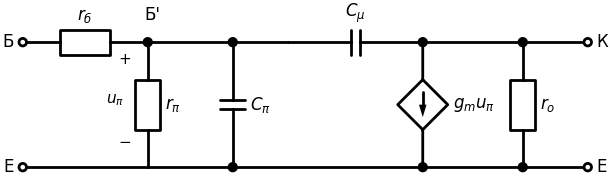

In [2]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=12, unit=2.5) as d:
        d.add(elm.Dot(open=True).at((0, 2.5)).label('Б', loc='left'))
        d.add(elm.Resistor().endpoints((0, 2.5), (2.5, 2.5)).label('$r_б$'))
        d.add(elm.Dot().at((2.5, 2.5))); d.add(elm.Label().at((2.5, 2.95)).label("Б'"))
        d.add(elm.Resistor().endpoints((2.5, 2.5), (2.5, 0)).label('$r_\\pi$', loc='bottom'))
        d.add(elm.Line().endpoints((2.5, 2.5), (4.2, 2.5))); d.add(elm.Dot().at((4.2, 2.5)))
        d.add(elm.Capacitor().endpoints((4.2, 2.5), (4.2, 0)).label('$C_\\pi$', loc='bottom'))
        d.add(elm.Line().endpoints((4.2, 2.5), (5.3, 2.5)))
        d.add(elm.Capacitor().endpoints((5.3, 2.5), (8, 2.5)).label('$C_\\mu$'))
        d.add(elm.Dot().at((8, 2.5)))
        d.add(elm.SourceControlledI().endpoints((8, 0), (8, 2.5)).reverse().label('$g_m u_\\pi$', loc='bottom'))
        d.add(elm.Line().endpoints((8, 2.5), (10, 2.5))); d.add(elm.Dot().at((10, 2.5)))
        d.add(elm.Resistor().endpoints((10, 2.5), (10, 0)).label('$r_o$', loc='bottom'))
        d.add(elm.Line().endpoints((10, 2.5), (11.3, 2.5))); d.add(elm.Dot(open=True).at((11.3, 2.5)).label('К', loc='right'))
        d.add(elm.Line().endpoints((2.5, 0), (11.3, 0))); d.add(elm.Dot(open=True).at((11.3, 0)).label('Е', loc='right'))
        d.add(elm.Line().endpoints((0, 0), (2.5, 0))); d.add(elm.Dot(open=True).at((0, 0)).label('Е', loc='left'))
        for xx in [4.2, 8, 10]: d.add(elm.Dot().at((xx, 0)))
        d.add(elm.Label().at((1.75, 1.25)).label('$u_\\pi$', fontsize=11))
        d.add(elm.Label().at((1.95, 2.05)).label('+', fontsize=11)); d.add(elm.Label().at((1.95, 0.4)).label('−', fontsize=11))

Стрілка керованого джерела $g_mu_\pi$ спрямована від колектора до емітера: при збільшенні $u_\pi$ (база «плюсує» відносно емітера) струм колектора n-p-n транзистора зростає.

---

# Частотні властивості <a class="anchor" id="bjt-frequency"></a>

На високих частотах струм бази дедалі більше витрачається на перезаряд $C_\pi$ і $C_\mu$, а не на керування колектором. Коефіцієнт передачі струму бази (при закороченому по змінному струму колекторі) спадає як однополюсна ланка:

$$h_{21е}(f) = \frac{\beta_0}{1 + jf/f_\beta}, \qquad f_\beta = \frac{1}{2\pi r_\pi(C_\pi + C_\mu)}.$$

Вище $f_\beta$ модуль спадає на 20 дБ/декаду, і добуток $|h_{21е}|\cdot f$ стає сталим — це **гранична частота** (частота одиничного підсилення)

$$f_T = \beta_0 f_\beta = \frac{g_m}{2\pi(C_\pi + C_\mu)}, \qquad \frac{1}{2\pi f_T} = \tau_F + \frac{\varphi_T}{I_к}(C_{бе} + C_\mu).$$

$f_T$ — головний довідниковий частотний параметр (2N3904 — 300 МГц, BFR92 — 5 ГГц, SiGe-транзистори — понад 300 ГГц). Він **залежить від струму**: при малих струмах $f_T$ зростає зі струмом (перезаряд бар'єрних ємностей через $1/g_m$), досягає максимуму ($\approx 1/2\pi\tau_F$) і спадає при великих струмах (ефект Кірка). У схемі СБ гранична частота коефіцієнта $\alpha$ $f_\alpha \approx f_T$ — у $\beta$ разів вища за $f_\beta$, тому СБ застосовують у НВЧ-каскадах.

### ⚙️ PySpice: частотна залежність h21е і гранична частота 2N3904 <a class="anchor" id="spice-ft"></a>

AC-аналіз: у базу втікає постійний струм зміщення і малий змінний струм, колектор закорочений по змінному струму джерелом 5 В. Змінюйте струм колектора і спостерігайте, як зміщується $f_\beta$ і $f_T$.

In [3]:
def h21_ac(Ib, Uce=5.0, model='Q2N3904'):
    c = Circuit('h21(f)'); c.include(lib('bjt'))
    c.I('b', c.gnd, 'b', Ib); c.I('ac', c.gnd, 'b', 'dc 0 ac 1')
    c.V('ce', 'c', c.gnd, Uce); c.BJT(1, 'c', 'b', c.gnd, model=model)
    an = c.simulator().ac(start_frequency=1e3, stop_frequency=10e9, number_of_points=40, variation='dec')
    op = c.simulator().operating_point()
    return np.array(an.frequency), np.abs(np.array(an.branches['vce'])), -float(op.branches['vce'][0])

def fT_of(f, h):
    k = np.argmin(abs(h - 10))            # на ділянці −20 дБ/дек: fT = f·|h21|
    return f[k]*h[k]

Ib_scan = np.logspace(-7.5, -3.5, 25)
scan = [h21_ac(ib) for ib in Ib_scan]
Ic_scan = np.array([s[2] for s in scan]); fT_scan = np.array([fT_of(s[0], s[1]) for s in scan])

def ft_plot(Ic_mA=2.0):
    ib = np.interp(np.log(Ic_mA*1e-3), np.log(Ic_scan), Ib_scan)
    f, h, Ic = h21_ac(ib)
    beta0 = h[0]; fb = f[np.argmin(abs(h - beta0/np.sqrt(2)))]; fT = fT_of(f, h)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    axes[0].loglog(f, h, color='#2563eb', lw=2)
    axes[0].axhline(1, color='gray', ls=':'); axes[0].axvline(fb, color='#16a34a', ls='--', lw=1); axes[0].axvline(fT, color='#dc2626', ls='--', lw=1)
    axes[0].text(fb*1.1, beta0*1.3, f'$f_\\beta$ = {fb/1e6:.2g} МГц', color='#16a34a'); axes[0].text(fT*1.1, 2, f'$f_T$ ≈ {fT/1e6:.0f} МГц', color='#dc2626')
    axes[0].set_ylim(0.1, 500); axes[0].set_xlabel('f, Гц'); axes[0].set_ylabel('$|h_{21е}|$'); axes[0].grid(True, which='both', alpha=0.3)
    axes[0].set_title(f'$|h_{{21е}}(f)|$ при $I_к$ = {Ic*1e3:.2f} мА')
    axes[1].semilogx(Ic_scan*1e3, fT_scan/1e6, color='#7c3aed', lw=2); axes[1].plot(Ic*1e3, fT/1e6, 'ro')
    axes[1].set_xlabel('$I_к$, мА'); axes[1].set_ylabel('$f_T$, МГц'); axes[1].set_title('Гранична частота як функція струму колектора')
    axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    print(f'β0 = {beta0:.0f}, f_β = {fb/1e6:.2f} МГц, β0·f_β = {beta0*fb/1e6:.0f} МГц ≈ f_T = {fT/1e6:.0f} МГц (довідник 2N3904: ≥ 300 МГц при 10 мА)')

interact(ft_plot, Ic_mA=widgets.FloatLogSlider(value=2.0, base=10, min=-1.5, max=1.7, step=0.1, description='$I_к$, мА',
                                               continuous_update=False));

interactive(children=(FloatLogSlider(value=2.0, continuous_update=False, description='$I_к$, мА', max=1.7, min…

---

# Підсилювальний каскад зі спільним емітером <a class="anchor" id="ce-amplifier"></a>

Типовий каскад СЕ: дільник $R_1R_2$ і резистор $R_е$ задають робочу точку з емітерною стабілізацією (Лекція 6); конденсатори $C_1$, $C_2$ **розділяють** постійні складові джерела сигналу, каскаду і навантаження; конденсатор $C_е$ **шунтує** $R_е$ на частотах сигналу. У середньочастотній області (ємності розділових і блокувального конденсаторів — «коротке замикання», ємності транзистора — «розрив»):

$$K_U = -g_m\,(R_к\,\|\,R_н\,\|\,r_o), \qquad R_{вх} = R_1\,\|\,R_2\,\|\,r_\pi, \qquad R_{вих} \approx R_к\,\|\,r_o.$$

Без шунтувального конденсатора $R_е$ створює від'ємний зворотний зв'язок за змінним струмом: підсилення падає до $K_U \approx -(R_к\|R_н)/R_е$, але стає стабільним, лінійним і майже не залежить від $\beta$. Знак «мінус» — **інверсія фази** на 180°.

**АЧХ каскаду** має три області: у **нижніх частотах** підсилення зменшують $C_1$, $C_2$ і особливо $C_е$ (їхній опір зростає); у **середніх** — стале $K_U$; у **верхніх** — ємності транзистора (передусім $C_\mu$, помножена ефектом Міллера).

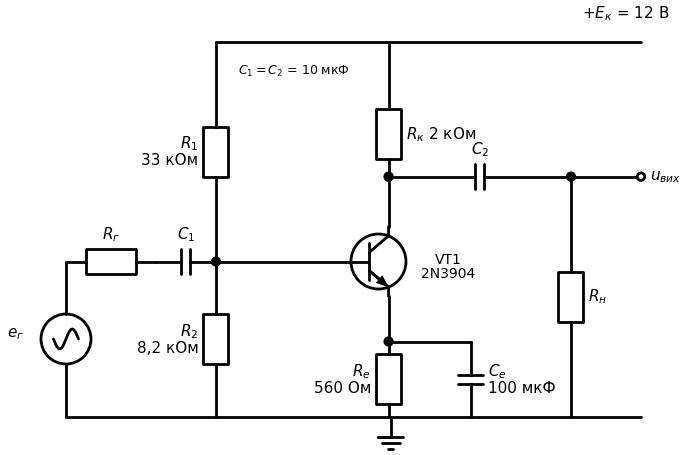

In [4]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.2) as d:
        top, bot = 6.0, -1.5
        t = d.add(elm.BjtNpn(circle=True).at((4.2, 1.6)).theta(0))
        yb = t.base[1]                                          # рівень бази — вузол дільника і вхідне коло
        d.add(elm.Line().endpoints((1.5, top), (10.0, top))); d.add(elm.Label().at((9.6, top + 0.45)).label('$+E_к$ = 12 В'))
        d.add(elm.Line().endpoints((-1.5, bot), (10.0, bot))); d.add(elm.Ground().at((5, bot)))
        d.add(elm.SourceSin().endpoints((-1.5, bot), (-1.5, yb))); d.add(elm.Label().at((-2.4, (bot + yb)/2)).label('$e_г$'))
        d.add(elm.Resistor().endpoints((-1.5, yb), (0.3, yb)).label('$R_г$'))
        d.add(elm.Capacitor().endpoints((0.3, yb), (1.5, yb)).label('$C_1$'))
        d.add(elm.Dot().at((1.5, yb)))
        d.add(elm.Resistor().endpoints((1.5, top), (1.5, yb)).label('$R_1$\n33 кОм', loc='top'))
        d.add(elm.Resistor().endpoints((1.5, yb), (1.5, bot)).label('$R_2$\n8,2 кОм', loc='top'))
        d.add(elm.Line().endpoints((1.5, yb), t.base))
        d.add(elm.Resistor().endpoints((t.collector[0], top), t.collector).label('$R_к$ 2 кОм', loc='bottom'))
        d.add(elm.Line().endpoints(t.emitter, (t.emitter[0], 0.0))); d.add(elm.Dot().at((t.emitter[0], 0.0)))
        d.add(elm.Resistor().endpoints((t.emitter[0], 0.0), (t.emitter[0], bot)).label('$R_е$\n560 Ом', loc='top'))
        d.add(elm.Line().endpoints((t.emitter[0], 0.0), (6.6, 0.0)))
        d.add(elm.Capacitor().endpoints((6.6, 0.0), (6.6, bot)).label('$C_е$\n100 мкФ', loc='bottom'))
        yc = t.collector[1] + 1.0
        d.add(elm.Dot().at((t.collector[0], yc)))
        d.add(elm.Capacitor().endpoints((t.collector[0], yc), (8.6, yc)).label('$C_2$'))
        d.add(elm.Dot().at((8.6, yc)))
        d.add(elm.Resistor().endpoints((8.6, yc), (8.6, bot)).label('$R_н$', loc='bottom'))
        d.add(elm.Line().endpoints((8.6, yc), (10.0, yc))); d.add(elm.Dot(open=True).at((10.0, yc)).label('$u_{вих}$', loc='right'))
        d.add(elm.Label().at((t.center[0] + 1.1, t.center[1] - 0.2)).label('VT1\n2N3904', fontsize=10))
        d.add(elm.Label().at((2.95, 5.3)).label('$C_1 = C_2$ = 10 мкФ', fontsize=9))

### ⚙️ PySpice: підсилювач СЕ — осцилограми і АЧХ <a class="anchor" id="spice-ce-amp"></a>

Змінюйте амплітуду вхідного сигналу (1 кГц), опір навантаження й наявність конденсатора $C_е$. При великих амплітудах вихідний сигнал обмежується відсіканням (транзистор закривається) і насиченням — з'являються **нелінійні спотворення**.

In [5]:
def ce_stage(Rg=600.0, Rn=10e3, bypass=True):
    c = Circuit('CE amplifier'); c.include(lib('bjt'))
    c.V('cc', 'vcc', c.gnd, 12)
    c.R('g', 'src', 'g', Rg); c.C('1', 'g', 'b', 10e-6)
    c.R('1', 'vcc', 'b', 33e3); c.R('2', 'b', c.gnd, 8.2e3)
    c.R('k', 'vcc', 'c', 2e3); c.R('e', 'e', c.gnd, 560)
    if bypass: c.C('e', 'e', c.gnd, 100e-6)
    c.C('2', 'c', 'out', 10e-6); c.R('n', 'out', c.gnd, Rn)
    c.BJT(1, 'c', 'b', 'e', model='Q2N3904')
    return c

def ce_amp(Um_mV=5.0, Rn_kOhm=10.0, bypass=True):
    c = ce_stage(Rn=Rn_kOhm*1e3, bypass=bypass)
    c.SinusoidalVoltageSource('in', 'src', c.gnd, amplitude=Um_mV*1e-3, frequency=1e3, ac_magnitude=1)
    op = c.simulator().operating_point()
    Ic = (12 - float(op['c'][0]))/2e3; gm = Ic/phi_T(300.15)
    tr = c.simulator().transient(step_time=2e-6, end_time=6e-3, max_time=5e-6)
    ac = c.simulator().ac(start_frequency=1, stop_frequency=1e9, number_of_points=30, variation='dec')
    t = np.array(tr.time)*1e3; uin = np.array(tr['src']); uout = np.array(tr['out'])
    f = np.array(ac.frequency); K = np.abs(np.array(ac['out']))
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
    m = t > 3
    ax = axes[0]; ax2 = ax.twinx()
    ax.plot(t[m], uout[m], color='#dc2626', lw=2, label='$u_{вих}$ (ліва вісь)')
    ax2.plot(t[m], uin[m]*1e3, color='#2563eb', lw=1.3, label='$e_г$, мВ (права вісь)')
    ax.set_xlabel('t, мс'); ax.set_ylabel('$u_{вих}$, В', color='#dc2626'); ax2.set_ylabel('$e_г$, мВ', color='#2563eb')
    ax.set_title(f'Осцилограми: $e_{{г.m}}$ = {Um_mV} мВ'); ax2.grid(False)
    Kmid = K[np.argmin(abs(f - 1e4))]
    axes[1].semilogx(f, 20*np.log10(K), color='#7c3aed', lw=2)
    axes[1].axhline(20*np.log10(Kmid) - 3, color='gray', ls=':', lw=1)
    band = f[K > Kmid/np.sqrt(2)]
    for fb in [band[0], band[-1]]: axes[1].axvline(fb, color='gray', ls='--', lw=1)
    axes[1].set_xlabel('f, Гц'); axes[1].set_ylabel('$20\\lg|K_{скв}|$, дБ'); axes[1].set_title('АЧХ наскрізного коефіцієнта підсилення $u_{вих}/e_г$')
    axes[1].grid(True, which='both', alpha=0.3)
    plt.tight_layout(); plt.show()
    upp = uout[m].max() - uout[m].min()
    print(f'Робоча точка: I_к = {Ic*1e3:.2f} мА, U_КЕ = {float(op["c"][0]) - float(op["e"][0]):.2f} В, g_m = {gm*1e3:.0f} мА/В')
    Rnet = 1/(1/2e3 + 1/(Rn_kOhm*1e3))
    theory = gm*Rnet if bypass else Rnet/560
    print(f'Підсилення на 10 кГц |u_вих/e_г| = {Kmid:.1f} ({20*np.log10(Kmid):.1f} дБ);  '
          f'|K_U| транзистора (теорія) ≈ {"g_m·(Rк‖Rн)" if bypass else "(Rк‖Rн)/Rе"} = {theory:.1f}')
    print(f'Смуга пропускання (−3 дБ): {band[0]:.3g} Гц … {band[-1]/1e6:.3g} МГц;  розмах вихідного сигналу {upp:.2f} В')
    print('(наскрізне підсилення менше за K_U на коефіцієнт вхідного дільника Rвх/(Rг + Rвх))')

interact(ce_amp, Um_mV=widgets.FloatLogSlider(value=5, base=10, min=0, max=2, step=0.1, description='$e_{г.m}$, мВ', continuous_update=False),
         Rn_kOhm=widgets.FloatLogSlider(value=10, base=10, min=-0.3, max=2, step=0.1, description='$R_н$, кОм', continuous_update=False),
         bypass=widgets.Checkbox(value=True, description='шунтувальний конденсатор $C_е$'));

interactive(children=(FloatLogSlider(value=5.0, continuous_update=False, description='$e_{г.m}$, мВ', max=2.0)…

## Ефект Міллера <a class="anchor" id="miller"></a>

Ємність $C_\mu$ з'єднує вхід каскаду СЕ (базу) з виходом (колектором), на якому змінна напруга в $K_U$ разів більша і протифазна. Струм через $C_\mu$ пропорційний різниці напруг $u_б - u_к = u_б(1 + |K_U|)$, тому для джерела сигналу $C_\mu$ еквівалентна ємності

$$C_{М} = C_\mu(1 + |K_U|), \qquad C_{вх} = C_\pi + C_\mu(1 + |K_U|), \qquad f_в \approx \frac{1}{2\pi R'_г C_{вх}},\quad R'_г = (R_г\|R_1\|R_2 + r_б)\,\|\,r_\pi.$$

При $K_U = 100$ і $C_\mu = 3$ пФ ефективна вхідна ємність зростає до сотень пікофарад — верхня гранична частота каскаду СЕ опускається до одиниць МГц, хоча $f_T$ транзистора — сотні МГц. Способи боротьби: **каскод** (СЕ + СБ — навантаження першого транзистора мале, $K_U \approx 1$), каскади СБ і СК, зменшення опору джерела сигналу, нейтралізація.

In [6]:
def miller(Rg_kOhm=0.6):
    c = ce_stage(Rg=Rg_kOhm*1e3, Rn=10e3, bypass=True)
    c.SinusoidalVoltageSource('in', 'src', c.gnd, ac_magnitude=1)
    an = c.simulator().ac(start_frequency=1e3, stop_frequency=1e9, number_of_points=40, variation='dec')
    f = np.array(an.frequency); K = np.abs(np.array(an['out'])); Kb = np.abs(np.array(an['b']))
    Kmid = K[np.argmin(abs(f - 1e4))]; fh = f[np.where(K > Kmid/np.sqrt(2))[0][-1]]
    fig, ax = plt.subplots(figsize=(9, 4.4))
    ax.loglog(f, K, color='#7c3aed', lw=2, label='$|u_{вих}/e_г|$')
    ax.loglog(f, Kb, color='#2563eb', lw=1.5, ls='--', label='$|u_б/e_г|$ — напруга на базі')
    ax.axvline(fh, color='gray', ls=':'); ax.text(fh*1.1, Kmid*0.3, f'$f_в$ = {fh/1e6:.2f} МГц')
    ax.set_xlabel('f, Гц'); ax.set_ylabel('коефіцієнт передачі'); ax.set_title(f'$R_г$ = {Rg_kOhm} кОм'); ax.legend(fontsize=9)
    ax.grid(True, which='both', alpha=0.3); ax.set_ylim(1e-3, 300)
    plt.tight_layout(); plt.show()
    op = c.simulator().operating_point()
    Uc, Ub, Ue = float(op['c'][0]), float(op['b'][0]), float(op['e'][0]); Ic = (12 - Uc)/2e3
    gm = Ic/phi_T(300.15); Ku = gm/(1/2e3 + 1/10e3 + Ic/74)                        # g_m·(Rк‖Rн‖r_o)
    Cmu = 3.638e-12/(1 + (Uc - Ub)/0.75)**0.3085                                  # CJC, VJC, MJC моделі 2N3904
    Ube = Ub - Ue; Cje = 4.493e-12/(0.5)**1.2593*(1 - 0.5*1.2593 + 0.2593*Ube/0.75)  # CJE при прямому зміщенні (FC = 0,5)
    Cpi = gm*301.2e-12 + Cje                                                      # g_m·TF + бар'єрна
    Rin = 1/(1/(Rg_kOhm*1e3) + 1/33e3 + 1/8.2e3) + 10; Req = 1/(1/Rin + gm/165)
    Cin = Cpi + Cmu*(1 + Ku)
    print(f'Оцінка: C_μ ≈ {Cmu*1e12:.1f} пФ, C_M = C_μ(1+|K_U|) ≈ {Cmu*(1+Ku)*1e12:.0f} пФ, C_π ≈ {Cpi*1e12:.0f} пФ → C_вх ≈ {Cin*1e12:.0f} пФ')
    print(f'f_в ≈ 1/(2π·R\'_г·C_вх) = {1/(2*np.pi*Req*Cin)/1e6:.2f} МГц (ngspice: {fh/1e6:.2f} МГц)')

interact(miller, Rg_kOhm=widgets.FloatLogSlider(value=0.6, base=10, min=-1.3, max=1.3, step=0.1, description='$R_г$, кОм',
                                                continuous_update=False));

interactive(children=(FloatLogSlider(value=0.6, continuous_update=False, description='$R_г$, кОм', max=1.3, mi…

---
### ✅ Питання для самоперевірки: Малосигнальна модель та каскад СЕ

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Як зміниться крутизна і вхідний опір $r_\pi$ транзистора, якщо струм колектора збільшити від 1 до 4 мА?</summary>

> **Відповідь:** $g_m = I_к/\varphi_T$ зросте вчетверо (з 38,7 до 155 мА/В), $r_\pi = \beta/g_m$ зменшиться вчетверо (при β = 150 — з 3,9 кОм до 0,97 кОм).

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Чому $f_T$ транзистора зростає зі струмом колектора при малих струмах?</summary>

> **Відповідь:** $1/2\pi f_T = \tau_F + (\varphi_T/I_к)(C_{бе} + C_\mu)$: при малих струмах переважає перезаряд бар'єрних ємностей через малосигнальний опір $1/g_m = \varphi_T/I_к$, який зменшується зі зростанням струму.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому шунтування $R_е$ конденсатором збільшує підсилення каскаду?</summary>

> **Відповідь:** Без $C_е$ змінна напруга на $R_е$ віднімається від вхідної (від'ємний зворотний зв'язок за струмом), і $K_U \approx R_к/R_е$. З $C_е$ емітер заземлений по змінному струму, і $K_U = g_mR_к$ — у $g_mR_е$ разів більше.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 4.</b> Чому ефект Міллера впливає на каскад СЕ, але майже не впливає на каскад СК?</summary>

> **Відповідь:** У СЕ вихід (колектор) інвертований і підсилений, тому напруга на $C_\mu$ в $(1 + |K_U|)$ разів більша за вхідну. У СК колектор заземлений по змінному струму, $C_\mu$ просто з'єднує вхід із землею, а $C_\pi$ до того ж «бутстрепується» виходом ($K_U \approx 1$).

</details>

---

# Транзистор у ключовому режимі <a class="anchor" id="bjt-switch"></a>

У ключовому режимі транзистор перемикається між **відсічкою** (ключ розімкнений, $I_к \approx 0$) і **насиченням** (ключ замкнений, $U_{КЕ.нас}$ ≈ 0,05–0,3 В). Щоб гарантувати насичення при розкиді β, струм бази беруть із запасом: **коефіцієнт насичення** $S = \beta I_б/I_{к.нас}$ = 2–10. Потужність у ключі мала в обох станах ($P \approx U_{КЕ.нас}I_к$ або $U_{КЕ}I_{КЕО}$), великі втрати виникають лише під час перемикання.

**Перехідні процеси** при подачі прямокутного імпульсу на базу:

| Інтервал | Що відбувається | Від чого залежить |
|---|---|---|
| $t_{зт}$ ($t_d$) — затримка ввімкнення | заряд бар'єрних ємностей до $U_{БЕ} \approx 0{,}6$ В | $C_{бе}$, $C_{бк}$, струм бази |
| $t_{нр}$ ($t_r$) — наростання | накопичення заряду в базі, $I_к$ зростає до $I_{к.нас}$ | $f_T$, $I_{б1}$ (швидше при великому $S$) |
| $t_{р}$ ($t_s$) — розсмоктування | після зняття сигналу виводиться **надлишковий** заряд насичення; $I_к$ ще не змінюється | $\tau_{н}$ і ступінь насичення: $t_s \approx \tau_н\ln\dfrac{I_{б1} + I_{б2}}{I_{к.нас}/\beta + I_{б2}}$ |
| $t_{сп}$ ($t_f$) — спадання | виведення активного заряду, $I_к$ спадає до нуля | $f_T$, зворотний струм бази $I_{б2}$ |

Великий запас насичення прискорює ввімкнення, але сповільнює вимкнення. Способи зменшити $t_s$: **форсувальний конденсатор** паралельно $R_б$ (кидок прямого і зворотного струму бази на фронтах), від'ємний струм бази $I_{б2}$ при вимкненні і **ключ Шотки** (діод Шотки між базою і колектором, «клямп Бейкера»). Діод Шотки відкривається, коли колектор опускається нижче бази на ≈0,3 В, відводить надлишковий струм бази і не дає транзистору увійти в глибоке насичення. Так побудовані ТТЛШ-мікросхеми (74LS, 74S, 74ALS).

### ⚙️ PySpice: перехідні процеси в транзисторному ключі <a class="anchor" id="spice-switch"></a>

Ключ на 2N2222A: $E_к$ = 10 В, $R_к$ = 1 кОм ($I_{к.нас}$ ≈ 10 мА); керувальний імпульс 0 → 5 В → 0 тривалістю 1 мкс через резистор бази $R_б$. Змінюйте $R_б$ (ступінь насичення) і вмикайте діод Шотки BAT54 між базою і колектором.

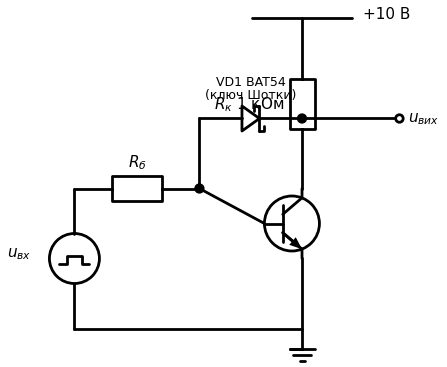

In [7]:
if SCHEMDRAW_AVAILABLE:
    with schemdraw.Drawing(fontsize=11, unit=2.2) as d:
        d.add(elm.SourcePulse().endpoints((0, -1), (0, 1.8))); d.add(elm.Label().at((-1.0, 0.4)).label('$u_{вх}$'))
        d.add(elm.Resistor().endpoints((0, 1.8), (2.5, 1.8)).label('$R_б$'))
        t = d.add(elm.BjtNpn(circle=True).at((3.8, 1.1)).theta(0))
        d.add(elm.Line().endpoints((2.5, 1.8), t.base)); d.add(elm.Dot().at((2.5, 1.8)))
        d.add(elm.Resistor().endpoints((t.collector[0], 5.2), t.collector).label('$R_к$ 1 кОм'))
        d.add(elm.Dot().at((t.collector[0], 3.2)))
        d.add(elm.Line().endpoints((2.5, 1.8), (2.5, 3.2)))
        d.add(elm.Schottky().endpoints((2.5, 3.2), (t.collector[0], 3.2)).label('VD1 BAT54\n(ключ Шотки)', fontsize=9))
        d.add(elm.Line().endpoints((t.collector[0], 3.2), (6.5, 3.2))); d.add(elm.Dot(open=True).at((6.5, 3.2)).label('$u_{вих}$', loc='right'))
        d.add(elm.Line().endpoints((t.collector[0] - 1.0, 5.2), (t.collector[0] + 1.0, 5.2))); d.add(elm.Label().at((t.collector[0] + 1.6, 5.2)).label('+10 В'))
        d.add(elm.Line().endpoints(t.emitter, (t.emitter[0], -1))); d.add(elm.Line().endpoints((0, -1), (t.emitter[0], -1)))
        d.add(elm.Ground().at((t.emitter[0], -1)))

In [8]:
def bjt_switch(Rb_kOhm=4.7, schottky=False):
    c = Circuit('BJT switch'); c.include(lib('bjt')); c.include(lib('diodes'))
    c.PulseVoltageSource('in', 'in', c.gnd, initial_value=0, pulsed_value=5, delay_time=0.2e-6,
                         rise_time=5e-9, fall_time=5e-9, pulse_width=1e-6, period=10e-6)
    c.R('b', 'in', 'b', Rb_kOhm*1e3)
    c.V('cc', 'vcc', c.gnd, 10); c.R('k', 'vcc', 'c', 1e3)
    c.BJT(1, 'c', 'b', c.gnd, model='Q2N2222A')
    if schottky: c.D('s', 'b', 'c', model='DBAT54')
    an = c.simulator().transient(step_time=1e-9, end_time=2.2e-6, max_time=2e-9)
    t = np.array(an.time)*1e6; uc = np.array(an['c']); ub = np.array(an['b']); ic = (10 - uc)/1e3
    Ib1 = (5 - 0.75)/(Rb_kOhm*1e3); S = 160*Ib1/(10e-3)
    fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True)
    axes[0].plot(t, np.array(an['in']), color='gray'); axes[0].set_ylabel('$u_{вх}$, В')
    axes[1].plot(t, ub, color='#16a34a'); axes[1].set_ylabel('$u_{БЕ}$, В')
    axes[2].plot(t, ic*1e3, color='#dc2626'); axes[2].set_ylabel('$i_к$, мА'); axes[2].set_xlabel('t, мкс')
    Imax = ic.max()
    k_on = np.argmax(ic > 0.9*Imax); t_off0 = 1.2 + 0.005
    k_s = np.where((t > t_off0) & (ic < 0.9*Imax))[0]; k_f = np.where((t > t_off0) & (ic < 0.1*Imax))[0]
    if len(k_s) and len(k_f):
        ts, tf = t[k_s[0]] - t_off0, t[k_f[0]] - t[k_s[0]]
        axes[2].axvspan(t_off0, t[k_s[0]], color='#fde68a', alpha=0.6); axes[2].axvspan(t[k_s[0]], t[k_f[0]], color='#bfdbfe', alpha=0.6)
        axes[2].text(t_off0 + 0.01, Imax*0.4, '$t_s$', fontsize=11); axes[2].text(t[k_f[0]] + 0.02, Imax*0.6, '$t_f$', fontsize=11)
    axes[0].set_title(f'$R_б$ = {Rb_kOhm} кОм, $I_{{б1}}$ ≈ {Ib1*1e3:.2f} мА, ступінь насичення S ≈ {S:.0f}' + (' + діод Шотки' if schottky else ''))
    plt.tight_layout(); plt.show()
    t_on = t[k_on] - 0.2
    print(f'Ввімкнення (до 0,9·Iк): {t_on*1e3:.0f} нс;  U_КЕ у ввімкненому стані = {uc[np.argmin(abs(t - 1.1))]:.3f} В')
    if len(k_s) and len(k_f): print(f'Розсмоктування t_s = {ts*1e3:.0f} нс,  спадання t_f = {tf*1e3:.0f} нс')

interact(bjt_switch, Rb_kOhm=widgets.SelectionSlider(options=[1.0, 2.2, 4.7, 10.0, 22.0, 47.0], value=4.7,
                                                     description='$R_б$, кОм', continuous_update=False),
         schottky=widgets.Checkbox(value=False, description='діод Шотки між базою і колектором'));

interactive(children=(SelectionSlider(continuous_update=False, description='$R_б$, кОм', index=2, options=(1.0…

---
### ⚡ Практичне застосування: Де працюють транзисторні ключі

<div style="background-color: #fffbeb; padding: 16px 18px; border-radius: 10px; border-left: 4px solid #f59e0b; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

Біполярні ключі керують реле, світлодіодами, двигунами і лампами від виходів мікроконтролерів, утворюють вихідні каскади ТТЛ-логіки і драйвери ліній. У потужній силовій електроніці біполярні транзистори значною мірою витіснили МДН-транзистори та IGBT (Лекція 10), але принцип «відсічка ↔ насичення» і проблема накопиченого заряду залишаються тими самими. При індуктивному навантаженні (реле, двигун) паралельно навантаженню обов'язково ставлять **зворотний діод**. Без нього під час вимкнення ЕРС самоіндукції пробиває колекторний перехід.

</div>

---
### ✅ Питання для самоперевірки: Ключовий режим

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 1.</b> Чому надмірний струм бази збільшує час вимкнення ключа?</summary>

> **Відповідь:** У глибокому насиченні в базі (і в колекторі) накопичується надлишковий заряд $\tau_н(I_б - I_{к.нас}/\beta)$, який треба вивести, перш ніж струм колектора почне спадати. Що більший $I_б$, то більший заряд і час розсмоктування $t_s$.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 2.</b> Як діод Шотки прискорює вимкнення ключа?</summary>

> **Відповідь:** Коли колекторна напруга опускається нижче базової приблизно на 0,3 В, діод Шотки відкривається і відводить надлишковий струм бази в колектор. Колекторний перехід не зміщується прямо настільки, щоб інжектувати, і транзистор не входить у глибоке насичення. Сам діод Шотки заряду неосновних носіїв не накопичує.

</details>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;"><b>Питання 3.</b> Чому потужність, яку розсіює ключ, мала в обох статичних станах?</summary>

> **Відповідь:** У відсічці малий струм ($I_{КЕО}$), у насиченні мала напруга ($U_{КЕ.нас}$) — добуток $UI$ малий. Основні втрати — динамічні, під час фронтів, коли одночасно великі і напруга, і струм.

</details>

---
### 📝 Задачі для самостійного розв'язання: Динамічний режим біполярного транзистора


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 1.** Транзистор працює при $I_к$ = 2 мА, β = 150. Знайдіть $g_m$ і $r_\pi$.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $g_m = I_к/\varphi_T = 2/25{,}85 = 77{,}4$ мА/В; $r_\pi = \beta/g_m = 150/0{,}0774 = 1{,}94$ кОм.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 2.** Транзистор має $\beta_0$ = 200, $f_T$ = 300 МГц. Знайдіть $f_\beta$ і модуль $h_{21е}$ на частоті 30 МГц.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $f_\beta = f_T/\beta_0 = 1{,}5$ МГц; на 30 МГц ($f \gg f_\beta$) $|h_{21е}| \approx f_T/f = 10$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 3.** Каскад СЕ з шунтованим $R_е$: $I_к$ = 3 мА, $R_к$ = 2 кОм, $R_н$ = 10 кОм. Знайдіть $K_U$. Яким буде $K_U$ без $C_е$, якщо $R_е$ = 560 Ом?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $g_m = 3/25{,}85 = 116$ мА/В; $R_к\|R_н = 1{,}67$ кОм; $K_U = -g_m(R_к\|R_н) \approx -193$. Без $C_е$: $K_U \approx -1667/560 \approx -3$.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 4.** $C_\mu$ = 2,5 пФ, $K_U$ = −190, $C_\pi$ = 40 пФ, еквівалентний опір джерела для входу 400 Ом. Оцініть верхню граничну частоту.

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $C_{вх} = C_\pi + C_\mu(1 + |K_U|) = 40 + 2{,}5\cdot191 = 518$ пФ; $f_в = 1/(2\pi\cdot400\cdot518\cdot10^{-12}) \approx 0{,}77$ МГц.

</details>


<div style="background-color: #fff1f2; padding: 12px 18px; border-radius: 10px; border-left: 4px solid #e11d48; box-shadow: 0 1px 3px rgba(0,0,0,0.08); margin: 10px 0;">

**Задача 5.** Ключ: $E_к$ = 10 В, $R_к$ = 1 кОм, β = 100, вхідний імпульс 5 В. Яким має бути $R_б$ для ступеня насичення S = 3?

</div>

<details style="margin: 10px 0; padding: 10px 14px; background: #ecfdf5; border-radius: 8px; border-left: 3px solid #0d9488;">
<summary style="cursor: pointer; font-weight: 600; color: #0f766e;">Відповідь і розв'язання</summary>

> $I_{к.нас} \approx 9{,}8$ мА; $I_б = S\,I_{к.нас}/\beta = 0{,}29$ мА; $R_б = (5 - 0{,}75)/0{,}29 \approx 14{,}5$ кОм → 15 кОм (ряд E24).

</details>

---

## 📌 Підсумок лекції 7: Біполярний транзистор у динамічному режимі <a class="anchor" id="summary"></a>

<div style="background-color: #f0fdf4; padding: 24px 18px; border-radius: 10px; border-left: 4px solid #16a34a; box-shadow: 0 1px 3px rgba(0,0,0,0.08);">

| Величина | Формула | Типові значення |
|---|---|---|
| Крутизна | $g_m = I_к/\varphi_T$ | 38,7 мА/В при 1 мА |
| Вхідний опір (П-модель) | $r_\pi = \beta/g_m$ | 1–10 кОм |
| Гранична частота | $f_T = g_m/2\pi(C_\pi + C_\mu) = \beta_0f_\beta$ | 100 МГц – 300 ГГц |
| Підсилення СЕ | $K_U = -g_m(R_к\|R_н\|r_o)$ | 50–300 |
| Ємність Міллера | $C_М = C_\mu(1 + |K_U|)$ | сотні пФ |
| Час розсмоктування | $t_s \approx \tau_н\ln\frac{I_{б1} + I_{б2}}{I_{к.нас}/\beta + I_{б2}}$ | 10 нс – мкс |

**Головні висновки.** (1) Малосигнальні параметри транзистора визначаються робочою точкою ($g_m$, $r_\pi$, $C_\pi \propto I_к$). (2) Частотні властивості обмежують заряд дифузійної ємності і перезаряд бар'єрних ємностей; у каскаді СЕ домінує ефект Міллера. (3) Каскад СЕ дає велике підсилення напруги з інверсією фази; шунтований $R_е$ збільшує підсилення, нешунтований — стабілізує і лінеаризує його. (4) Швидкодію ключа обмежує насичення; ключ Шотки і форсувальні ланцюги зменшують час розсмоктування.

</div>

---

## 📚 Рекомендована література та ресурси <a class="anchor" id="references"></a>

**Основна література**

1. Прищепа М. М., Погребняк В. П. Мікроелектроніка. Ч. 1. Елементи мікроелектроніки: навч. посібник. — К.: Вища школа, 2004.
2. Бойко В. І., Гуржій А. М., Жуйков В. Я. та ін. Схемотехніка електронних систем. Кн. 1. Аналогова схемотехніка та імпульсні пристрої. — К.: Вища школа, 2004.
3. Sze S. M., Ng K. K. Physics of Semiconductor Devices. — 3rd ed. — Wiley, 2007.
4. Neamen D. A. Semiconductor Physics and Devices: Basic Principles. — 4th ed. — McGraw-Hill, 2012.

**Додаткова література**

5. Sedra A. S., Smith K. C. Microelectronic Circuits. — 8th ed. — Oxford University Press, 2020.
6. Streetman B. G., Banerjee S. K. Solid State Electronic Devices. — 7th ed. — Pearson, 2016.

**Програмні інструменти, що використовуються в конспекті**

- [PySpice](https://pyspice.fabrice-salvaire.fr/) + [ngspice](https://ngspice.sourceforge.io/) — схемотехнічне моделювання (SPICE-моделі приладів — у теці `models/`)
- [SchemDraw](https://schemdraw.readthedocs.io/) — побудова електричних схем
- [NumPy](https://numpy.org/doc/) / [SciPy](https://docs.scipy.org/doc/scipy/) / [Matplotlib](https://matplotlib.org/) — чисельні розрахунки та графіки
- [ipywidgets](https://ipywidgets.readthedocs.io/) — інтерактивні елементи керування

---

<p style="text-align: center;">⬅️ [Лекція 6. Статичні характеристики та параметри біполярного транзистора](Лекція_06_Статичні_характеристики_біполярного_транзистора.ipynb) &nbsp;|&nbsp; [Лекція 8. Польові транзистори з керуючим p-n переходом](Лекція_08_Польові_транзистори_з_керуючим_pn_переходом.ipynb) ➡️</p>

*Конспект підготовлено: Пахалюк Богдан Петрович, НУ "Чернігівська політехніка"*